In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [18]:
# p-value thresholds
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
        phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
        region = pl.col('gene_id'),
        gene_name = pl.col('gene_symbol'),
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('trait_type') == 'continuous') &
        # (pl.col('annotation').str.contains('pLoF'))
        (pl.col('annotation') == 'pLoF')
    )
    # .select(['region', 'gene_name', 'phenotype', 'trait_type'])
    # .unique()
)

gb_pl.filter(pl.col('gene_name') == 'HBB').sort('Pvalue')

gene_id,gene_symbol,annotation,trait_type,phenocode,pheno_sex,coding,modifier,description,coding_description,Pvalue,Pvalue_Burden,Pvalue_SKAT,significant,phenotype,region,gene_name
str,str,str,str,str,str,str,str,str,str,f64,f64,f64,bool,str,str,str
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30040""","""both_sexes""","""""","""irnt""","""Mean corpuscular volume""",null,1.1637e-125,2.3007e-125,2.8797e-82,true,"""mean_corpuscular_volume_int""","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30050""","""both_sexes""","""""","""irnt""","""Mean corpuscular haemoglobin""",null,3.1690e-122,7.5598e-122,2.3734e-80,true,"""mean_corpuscular_haemoglobin_i…","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30010""","""both_sexes""","""""","""irnt""","""Red blood cell (erythrocyte) c…",null,6.7044e-83,4.8869e-83,1.6225e-54,true,"""red_blood_cell_erythrocyte_cou…","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30270""","""both_sexes""","""""","""irnt""","""Mean sphered cell volume""",null,3.1842e-72,6.3652e-72,1.4169e-49,true,"""mean_sphered_cell_volume_int""","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30020""","""both_sexes""","""""","""irnt""","""Haemoglobin concentration""",null,5.1237e-67,1.2926e-67,2.1147e-43,true,"""haemoglobin_concentration_int""","""ENSG00000244734""","""HBB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30260""","""both_sexes""","""""","""irnt""","""Mean reticulocyte volume""",null,3.2411e-27,4.6301e-28,2.6041e-17,true,"""mean_reticulocyte_volume_int""","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30300""","""both_sexes""","""""","""irnt""","""High light scatter reticulocyt…",null,1.5394e-18,1.1001e-18,1.4067e-14,true,"""high_light_scatter_reticulocyt…","""ENSG00000244734""","""HBB"""
"""ENSG00000244734""","""HBB""","""pLoF""","""continuous""","""30250""","""both_sexes""","""""","""irnt""","""Reticulocyte count""",null,5.3061e-18,2.2828e-18,1.2061e-13,true,"""reticulocyte_count_int""","""ENSG00000244734""","""HBB"""


# Single gene-trait association plots

In [19]:
## Single gene-trait association plot
gene_name = 'HBB'
phenotype = 'mean_corpuscular_volume_int'

In [20]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [21]:
exp_data = pl.read_csv('/home/dnanexus/data_dir/exp_data/kircher_all_enhancers_and_promoters.tsv', separator='\t').drop(['pos']).rename({
    'locus': 'gene_name',
    'Chromosome': 'chrom',
    'variant_pos': 'pos',
}).with_columns(
    id = pl.col("chrom") + ":" + pl.col("pos").cast(pl.Utf8) + ":" + pl.col("ref") + ":" + pl.col("alt"),
).select(['id', 'gene_name', 'log2FC'])

exp_data['gene_name'].value_counts(sort=True).head(10)

gene_name,count
str,u64
"""SORT1""",1758
"""IRF6""",1734
"""MYCrs6983267""",1668
"""ZFAND3""",1647
"""MSMB""",1641
"""PKLR""",1383
"""IRF4""",1326
"""GP1BB""",1119
"""LDLR""",928


In [22]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet").filter(pl.col('gene_name') == gene_name).collect(engine='streaming')

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
)
anno

id,abexp_max,am_pathogenicity,abexp_min,esmscoremissense,Strand,promoterai_abs,promoterai_under,delta_score,gene_name,promoterai_over,gpn_score,TSS,promoterai,dist_to_tss,region,verphylop,absplice2_max,relative_cds_position,cadd_raw,zooverphylop,gene_length,pangolin_score,absplice_dna_max
str,f64,f32,f64,f32,cat,f32,f32,f32,str,f32,f32,i64,f32,i64,str,f32,f32,f32,f32,f32,i64,f32,f32
"""chr11:5227429:G:T""",0.006871,0.0,-0.019552,0.0,"""-""",0.0082,-0.0082,0.0,"""HBB""",0.0,-1.61,5229395,-0.0082,1966,"""ENSG00000244734""",0.078,0.002461,0.0,0.212258,-0.014,3933,0.01,0.003
"""chr11:5226924:A:C""",-0.27997,0.0,-0.363257,0.0,"""-""",0.0004,-0.0004,0.69,"""HBB""",0.0,-4.73,5229395,-0.0004,2471,"""ENSG00000244734""",0.973,0.585824,0.0,2.259861,3.505,3933,0.7,0.294
"""chr11:5229985:C:T""",0.002469,0.0,-0.019552,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,-0.18,5229395,0.0,-590,"""ENSG00000244734""",-1.313,0.0,0.0,-0.581232,-1.887,3933,0.0,0.0
"""chr11:5232324:T:C""",0.002469,0.0,-0.019552,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,-1.04,5229395,0.0,-2929,"""ENSG00000244734""",-0.024,0.0,0.0,0.179827,0.139,3933,0.0,0.0
"""chr11:5225428:T:C""",0.002469,0.0,-0.019552,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,0.64,5229395,0.0,3967,"""ENSG00000244734""",-0.697,0.0,0.0,0.012188,0.036,3933,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:5230860:T:A""",null,0.0,null,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,-1.17,5229395,0.0,-1465,"""ENSG00000244734""",0.469,0.0,0.0,0.48903,-0.585,3933,0.0,0.0
"""chr11:5220996:CTG:C""",null,0.0,null,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,-1.46,5229395,0.0,8399,"""ENSG00000244734""",0.042,0.0,0.0,-0.22262,-0.146,3933,0.0,0.0
"""chr11:5220858:T:G""",null,0.0,null,0.0,"""-""",0.0,0.0,0.0,"""HBB""",0.0,-0.55,5229395,0.0,8537,"""ENSG00000244734""",0.104,0.0,0.0,0.276985,0.11,3933,0.0,0.0


In [23]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr11:5227429:G:T""","""ENSG00000244734""","""cadd_raw""",0.212258
"""chr11:5226924:A:C""","""ENSG00000244734""","""cadd_raw""",2.259861
"""chr11:5229985:C:T""","""ENSG00000244734""","""cadd_raw""",-0.581232
"""chr11:5232324:T:C""","""ENSG00000244734""","""cadd_raw""",0.179827
"""chr11:5225428:T:C""","""ENSG00000244734""","""cadd_raw""",0.012188
…,…,…,…
"""chr11:5230860:T:A""","""ENSG00000244734""","""abexp_max""",null
"""chr11:5220996:CTG:C""","""ENSG00000244734""","""abexp_max""",null
"""chr11:5220858:T:G""","""ENSG00000244734""","""abexp_max""",null


In [24]:
# Get phenotype data for the phenotype of interest
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet").filter(pl.col('phenotype') == phenotype).collect(engine='streaming')

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

# Join with experimental data
pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,gene_name_right,log2FC
str,str,u32,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,f64
"""chr11:5227104:C:T""","""mean_corpuscular_volume_int""",3,-0.831196,0.403792,"""ENSG00000244734""","""cadd_raw""",1.640883,5229395,"""-""",3933,"""HBB""",2291,"""HBB""",-0.04
"""chr11:5227170:C:T""","""mean_corpuscular_volume_int""",1,1.630423,null,"""ENSG00000244734""","""cadd_raw""",0.276986,5229395,"""-""",3933,"""HBB""",2225,"""HBB""",0.05
"""chr11:5227143:A:T""","""mean_corpuscular_volume_int""",1,0.020861,null,"""ENSG00000244734""","""cadd_raw""",2.008287,5229395,"""-""",3933,"""HBB""",2252,"""HBB""",-0.29
"""chr11:5227063:A:C""","""mean_corpuscular_volume_int""",1,0.669546,null,"""ENSG00000244734""","""cadd_raw""",2.546649,5229395,"""-""",3933,"""HBB""",2332,"""HBB""",0.07
"""chr11:5227130:C:T""","""mean_corpuscular_volume_int""",1,-0.598422,null,"""ENSG00000244734""","""cadd_raw""",0.466515,5229395,"""-""",3933,"""HBB""",2265,"""HBB""",-0.05
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:5227141:A:G""","""mean_corpuscular_volume_int""",22,-0.223517,0.655271,"""ENSG00000244734""","""abexp_max""",0.00348,5229395,"""-""",3933,"""HBB""",2254,"""HBB""",0.24
"""chr11:5227158:G:A""","""mean_corpuscular_volume_int""",5,-2.384709,0.221624,"""ENSG00000244734""","""abexp_max""",0.017212,5229395,"""-""",3933,"""HBB""",2237,"""HBB""",-0.28
"""chr11:5227205:C:G""","""mean_corpuscular_volume_int""",2,0.668994,0.22764,"""ENSG00000244734""","""abexp_max""",0.006871,5229395,"""-""",3933,"""HBB""",2190,"""HBB""",0.11


In [25]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",47
"""am_pathogenicity""",47
"""esmscoremissense""",47
"""gpn_score""",47
"""zooverphylop""",47
…,…
"""promoterai_abs""",47
"""promoterai_under""",47
"""promoterai_over""",47


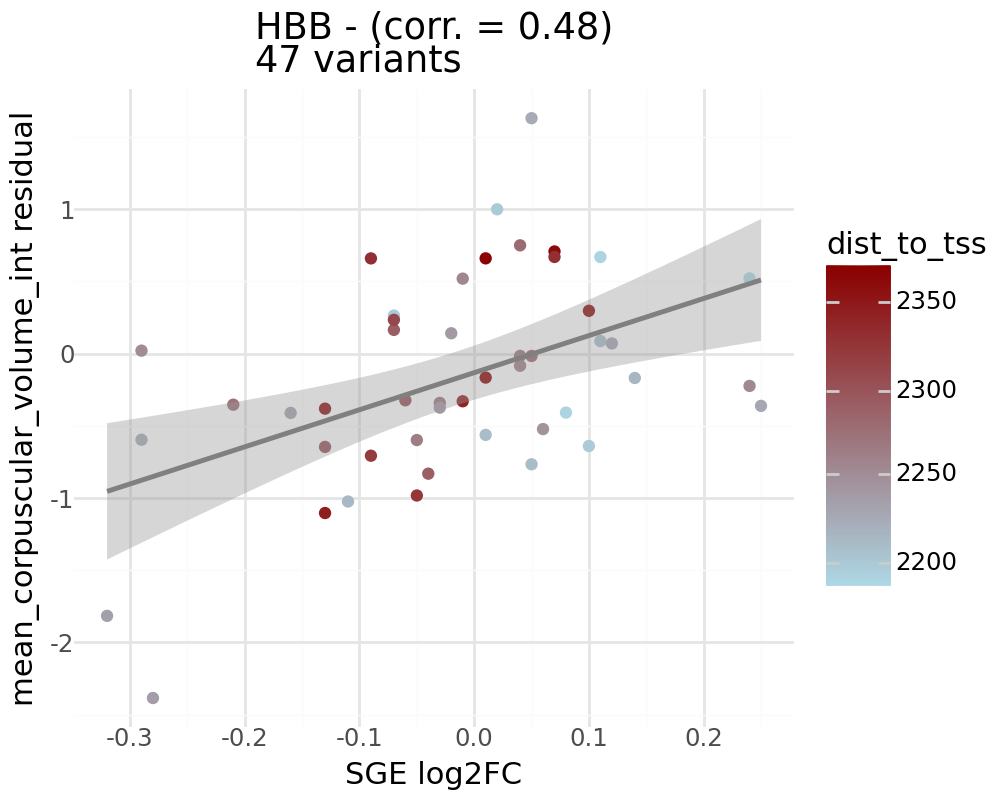

In [32]:
plot_df = pg_df[['id', 'n_individuals', 'dist_to_tss', 'mean_pheno_value', 'log2FC']].unique()

(
    ggplot(plot_df, aes(x='log2FC', y='mean_pheno_value', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x="SGE log2FC",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('log2FC', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

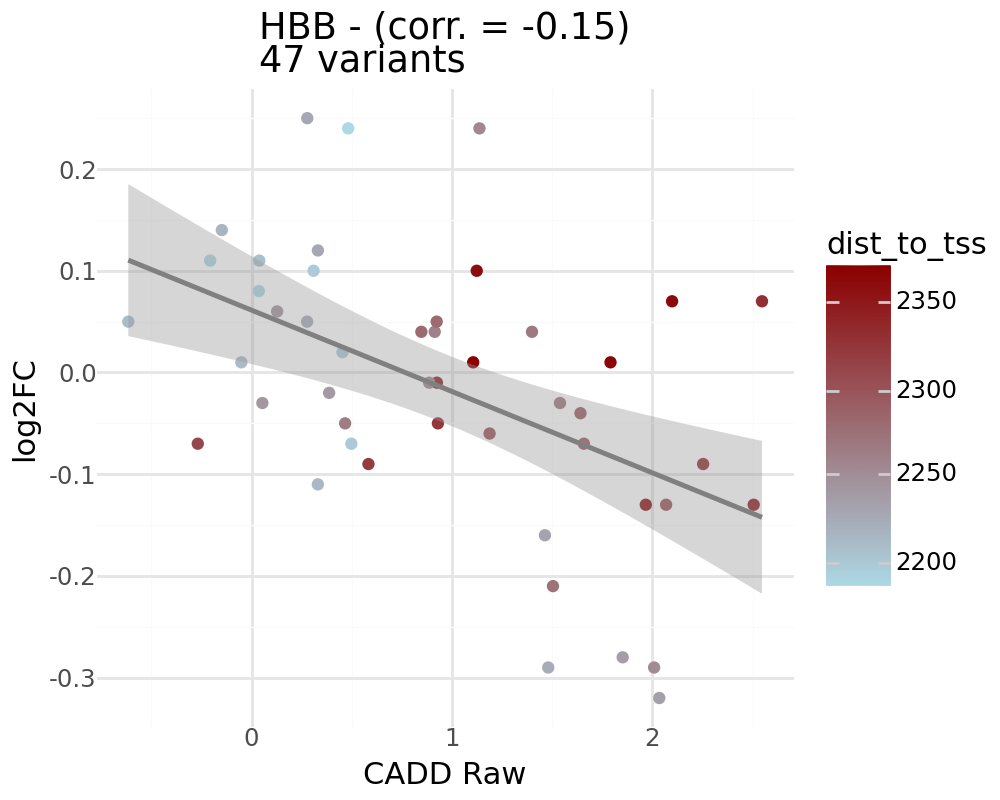

In [42]:
annotation = 'cadd_raw'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='log2FC', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        # y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

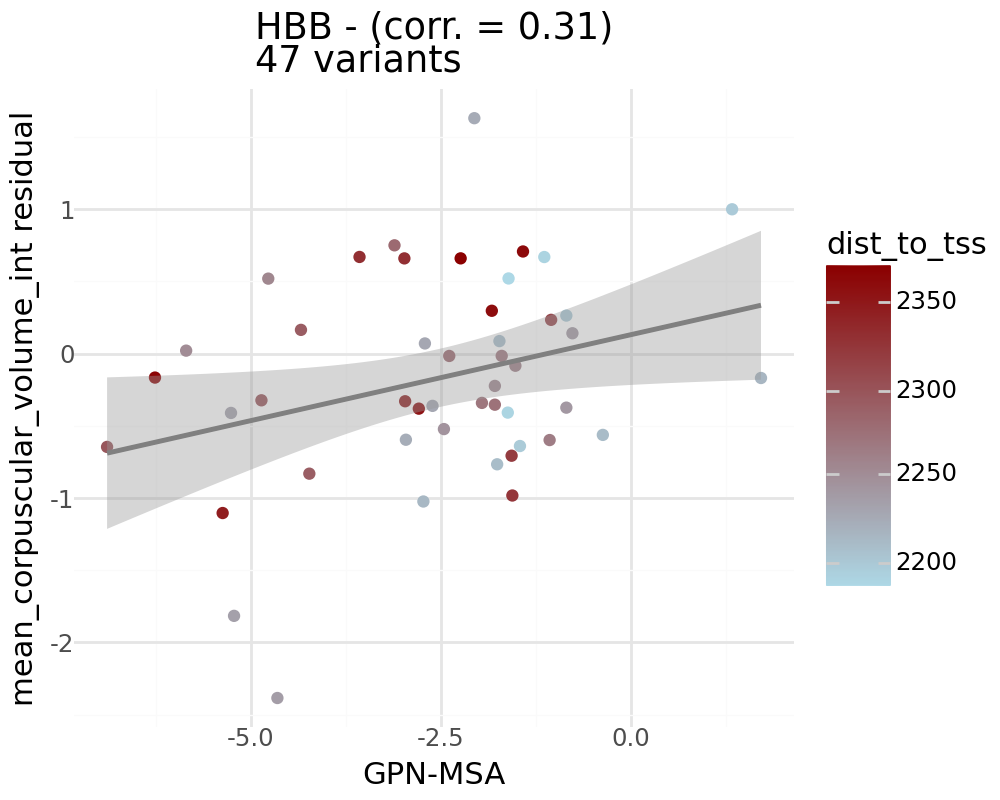

In [38]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

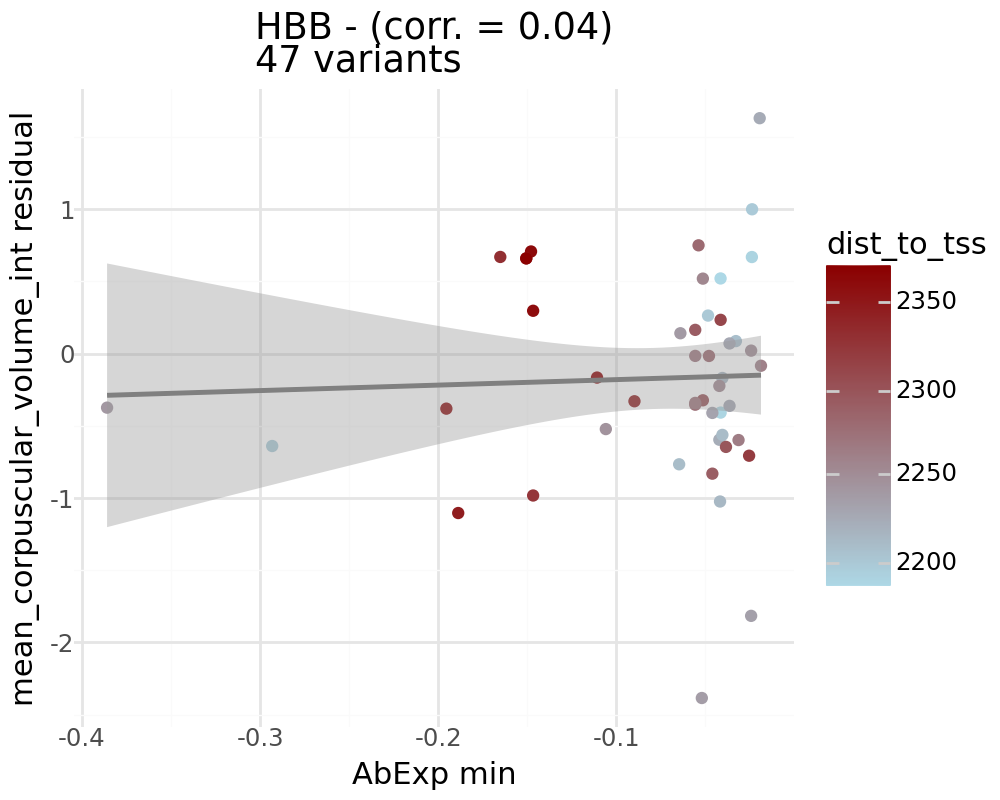

In [39]:
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

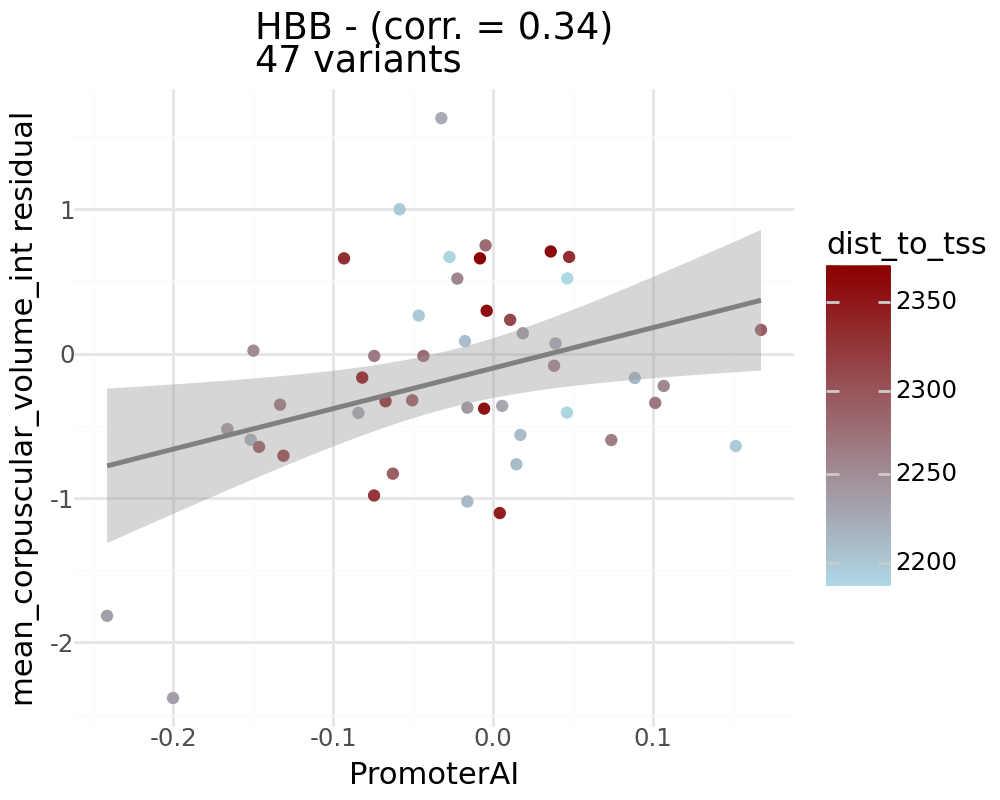

In [40]:
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)